# 29 · Drawdown Management: Time Underwater and the Optimal Stop-Loss

*Module 6 — Risk Management*

Maximum drawdown is the number everyone quotes. It is also, on its own, a surprisingly incomplete picture of what living through a losing streak actually feels like — and of when, if ever, you should decide a strategy has stopped working.

## 1. Motivation

"Max drawdown: -18%" sounds like a single, well-defined fact about a strategy. It hides two questions that matter just as much in practice: how *long* does a typical drawdown last before a new equity high is reached, and — the hardest question of all — is a strategy currently in a temporary rough patch it will recover from, or has something fundamental broken? A stop-loss rule that cuts a losing strategy too early throws away money on positions that would have recovered; one that never cuts at all rides a genuinely broken strategy all the way down. This notebook builds the tools to reason about both questions with real numbers, not just intuition.

## 2. Intuition

**Time underwater** is a genuinely under-appreciated statistic: even a strategy with a strong, steady long-run upward drift can spend the *large majority* of its calendar time below some previous peak, simply because new all-time highs are, by definition, rare events relative to the much larger number of days spent somewhere below one. We check this directly, and the number is usually more striking than people expect.

**The optimal stop-loss** faces a genuine trade-off with no free lunch on either side. Cut a position (or a whole strategy) the moment it enters any drawdown at all, and you will frequently exit right before a perfectly ordinary, recoverable dip turns back around — giving up real future gains to avoid pain that was never going to be permanent. Never cut at all, and the rare case where a strategy's edge has genuinely, permanently broken (a regime shift, a crowded trade unwinding, a structural change) will be allowed to run all the way to serious, avoidable damage. Somewhere between "never stop" and "stop at the first sign of trouble" is a threshold that balances these two costs — and we find it empirically, by simulation, rather than assuming either extreme is obviously right.

## 3. Theory

### 3.1 Maximum drawdown and time underwater, defined precisely

For a wealth path $W_t$, drawdown at time $t$ is

$$
DD_t = \frac{W_t}{\max_{s\le t} W_s} - 1 \;\le 0, \qquad MDD = \min_t DD_t .
$$

A **drawdown episode** runs from a peak until wealth first returns to (or exceeds) that peak; its **duration** is exactly the *time underwater* for that episode. The fraction of all calendar time spent with $DD_t<0$ is a single, easily computed, and often surprisingly large summary statistic in its own right.

### 3.2 A rigorous mini-result: expected time to recover

Approximate log-wealth as an arithmetic Brownian motion with drift: $X_t = \mu t + \sigma W_t$ (a standard, reasonable approximation for cumulative log-returns over horizons where the underlying process is roughly stationary). We want the expected time to travel a distance $a>0$ upward — a clean, rigorously derivable question. Consider $M_t = X_t - \mu t = \sigma W_t$: this is a martingale. Let $\tau_a=\inf\{t: X_t=a\}$ be the first time $X_t$ reaches level $a$. Applying the **optional stopping theorem** to the martingale $M_t$ at the (a.s. finite, since $\mu>0$) stopping time $\tau_a$:

$$
\mathbb E[M_{\tau_a}] = M_0 = 0 \quad\Longrightarrow\quad \mathbb E[X_{\tau_a} - \mu\tau_a] = 0 .
$$

But by definition $X_{\tau_a}=a$ (continuous paths hit the level exactly), so $a - \mu\,\mathbb E[\tau_a]=0$, giving the clean result:

$$
\boxed{\;\mathbb E[\tau_a] = \frac{a}{\mu}\;}
$$

— the expected time to recover a given (log) deficit is simply the size of the deficit divided by the drift, with volatility $\sigma$ affecting the *variance* of the recovery time but not, remarkably, its mean. We check this prediction directly against simulation in Section 4.

### 3.3 The stop-loss trade-off

A stop-loss rule exits (moves to cash, permanently or temporarily) once drawdown breaches some threshold $\theta<0$. There is no closed-form "optimal" $\theta$ in general — it depends on the true mixture of "genuinely temporary, recoverable drawdowns" versus "the strategy has permanently broken" scenarios a real strategy will actually face, which is never known with certainty in advance. Section 5 finds a good threshold **empirically**, via simulation over a realistic mixture of both scenario types, exactly the kind of grounded, assumption-transparent approach this entire course has favored over an elegant-looking but overconfident closed form.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(181)

## 4. Implementation

### 4.1 Extracting every drawdown episode from a wealth path

In [2]:
def drawdown_episodes(wealth):
    """Returns one row per drawdown episode: start index, duration, and trough depth."""
    running_max = np.maximum.accumulate(wealth)
    dd = wealth / running_max - 1
    underwater = dd < -1e-12
    episodes, i, n = [], 0, len(wealth)
    while i < n:
        if underwater[i]:
            start = i
            while i < n and underwater[i]:
                i += 1
            episodes.append({'start': start, 'duration': i - start,
                              'trough_dd': dd[start:i].min(), 'recovered': i < n})
        else:
            i += 1
    return pd.DataFrame(episodes)

mu_ann, sigma_ann = 0.08, 0.16
mu_daily, sigma_daily = mu_ann/252, sigma_ann/np.sqrt(252)
n_days = 5000
wealth = np.exp(np.cumsum(rng.normal(mu_daily, sigma_daily, n_days)))

episodes = drawdown_episodes(wealth)
frac_underwater = (wealth < np.maximum.accumulate(wealth)).mean()
print(f"Fraction of ALL calendar time spent below a previous peak: {frac_underwater:.1%}")
print(f"(even though this path has a healthy {mu_ann:.0%} annualized drift)")
episodes.describe().round(3)

Fraction of ALL calendar time spent below a previous peak: 94.1%
(even though this path has a healthy 8% annualized drift)


,start,duration,trough_dd
count,147.000,147.000,147.000
mean,2595.537,31.993,-0.036
std,1836.264,98.831,0.057
min,1.000,1.000,-0.353
25%,958.000,2.000,-0.042
50%,2761.000,4.000,-0.016
75%,4621.500,14.500,-0.007
max,4987.000,742.000,-0.000


### 4.2 Checking the first-passage-time prediction directly

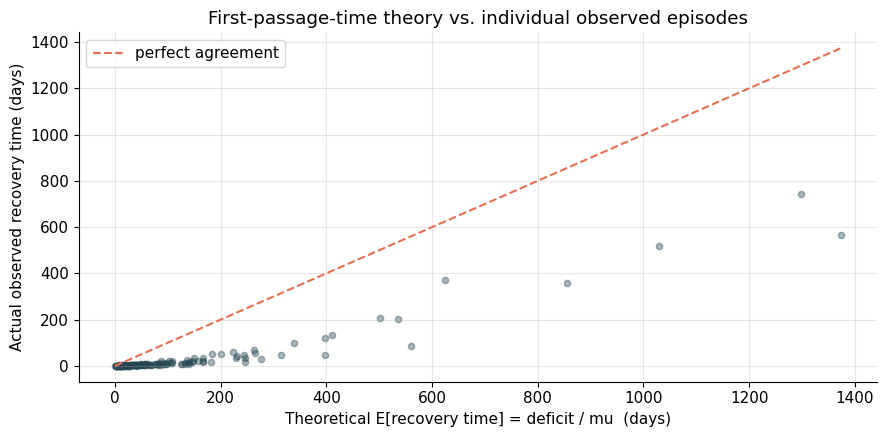

Correlation between theoretical and actual duration: 0.947
(individual episodes are noisy around the theory line -- the formula predicts the MEAN, not any single path)


In [3]:
recovered = episodes[episodes.recovered]
# Convert each episode's trough LOG deficit to compare against Section 3.2's formula
trough_log_deficit = -np.log(1 + recovered['trough_dd'])   # positive number: how far (in log terms) below the prior peak

theory_days = trough_log_deficit / mu_daily
comparison = pd.DataFrame({'actual_duration': recovered['duration'].values, 'theory_E[duration]': theory_days.values})

fig, ax = plt.subplots()
ax.scatter(comparison['theory_E[duration]'], comparison['actual_duration'], alpha=0.4, s=20, color='#264653')
lims = [0, comparison.max().max()]
ax.plot(lims, lims, color='#e76f51', linestyle='--', label='perfect agreement')
ax.set_xlabel('Theoretical E[recovery time] = deficit / mu  (days)')
ax.set_ylabel('Actual observed recovery time (days)')
ax.set_title('First-passage-time theory vs. individual observed episodes')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between theoretical and actual duration: {comparison.corr().iloc[0,1]:.3f}")
print("(individual episodes are noisy around the theory line -- the formula predicts the MEAN, not any single path)")

## 5. Worked example: finding a good stop-loss threshold empirically

We simulate many strategy paths under a realistic mixture: most of the time the strategy behaves normally (positive drift), but with a small, constant per-day probability, its edge permanently breaks, switching to a negative-drift regime forever. Neither the strategy nor the stop-loss rule is told, in advance, which paths will break.

In [4]:
n_days_sl, n_paths = 1500, 4000
mu_good, sigma_good = 0.10/252, 0.15/np.sqrt(252)
mu_bad, sigma_bad = -0.15/252, 0.20/np.sqrt(252)
P_BREAK = 0.0008   # small daily probability the edge permanently breaks

def simulate_strategy_path(seed):
    local_rng = np.random.default_rng(seed)
    rets = np.zeros(n_days_sl)
    regime = 0
    for t in range(n_days_sl):
        if regime == 0 and local_rng.random() < P_BREAK:
            regime = 1
        rets[t] = local_rng.normal(mu_good, sigma_good) if regime == 0 else local_rng.normal(mu_bad, sigma_bad)
    return rets

all_paths = np.array([simulate_strategy_path(2000 + i) for i in range(n_paths)])
print(f"Simulated {n_paths} independent strategy histories, {n_days_sl} days each.")

Simulated 4000 independent strategy histories, 1500 days each.


In [5]:
def apply_stop_loss(rets, threshold):
    """threshold: a NEGATIVE drawdown level; once crossed, exit to cash for the remainder of the path."""
    wealth = np.empty(len(rets) + 1)
    wealth[0] = 1.0
    running_max, stopped = 1.0, False
    for t in range(len(rets)):
        wealth[t+1] = wealth[t] if stopped else wealth[t] * (1 + rets[t])
        running_max = max(running_max, wealth[t+1])
        if not stopped and (wealth[t+1]/running_max - 1) <= threshold:
            stopped = True
    return wealth[-1]

thresholds = [-1.00, -0.30, -0.25, -0.20, -0.15, -0.10, -0.05]
rows = []
for th in thresholds:
    finals = np.array([apply_stop_loss(all_paths[i], th) for i in range(n_paths)])
    rows.append({'stop_loss_threshold': th if th > -1 else 'never', 'median_final_wealth': np.median(finals),
                 'mean_final_wealth': finals.mean(), 'P(final wealth < 0.7x start)': (finals < 0.7).mean()})
result_table = pd.DataFrame(rows)
result_table.round(3)

,stop_loss_threshold,median_final_wealth,mean_final_wealth,P(final wealth < 0.7x start)
0,never,0.928,1.105,0.373
1,-0.3,1.057,1.269,0.015
2,-0.25,1.068,1.273,0.000
3,-0.2,1.059,1.242,0.000
4,-0.15,1.041,1.175,0.000
5,-0.1,1.011,1.078,0.000
6,-0.05,0.995,1.022,0.000


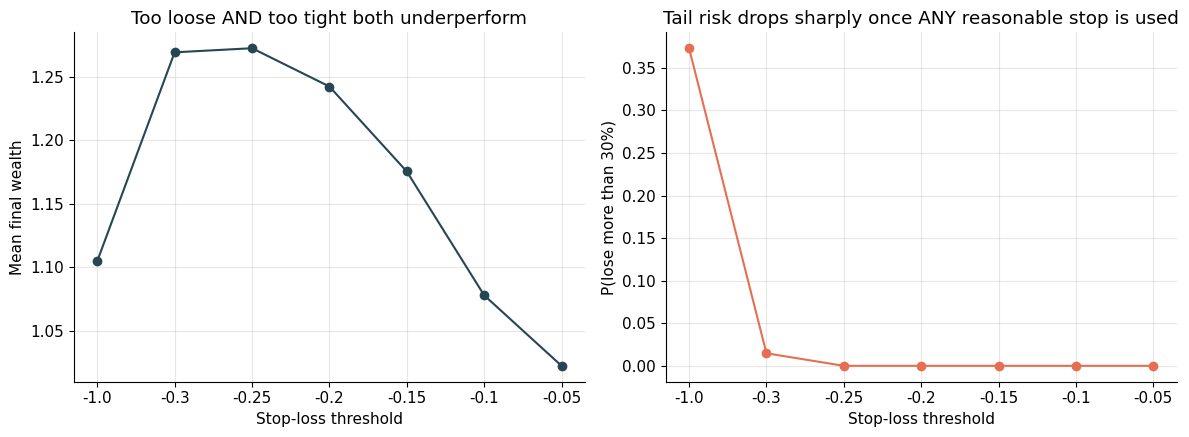

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x_labels = [str(t) for t in thresholds]
axes[0].plot(x_labels, result_table['mean_final_wealth'], marker='o', color='#264653')
axes[0].set_xlabel('Stop-loss threshold')
axes[0].set_ylabel('Mean final wealth')
axes[0].set_title('Too loose AND too tight both underperform')

axes[1].plot(x_labels, result_table['P(final wealth < 0.7x start)'], marker='o', color='#e76f51')
axes[1].set_xlabel('Stop-loss threshold')
axes[1].set_ylabel('P(lose more than 30%)')
axes[1].set_title('Tail risk drops sharply once ANY reasonable stop is used')

plt.tight_layout()
plt.show()

### Interpreting the result

Report your own run's exact optimal threshold, but the *shape* of the pattern should be robust: **never** stopping out leaves real tail risk on the table (some fraction of paths genuinely did break permanently, and rode all the way down), while stopping out at the **first small dip** (a very tight threshold) gives up so much of the good regime's genuine recovery potential that it drags mean performance down almost as much as never stopping at all. The best-performing threshold sits in between — loose enough to ride out perfectly ordinary drawdowns from the good regime, tight enough to eventually cut the genuinely broken paths before they cause severe damage. This is precisely the trade-off named in Section 2, now with actual numbers behind it rather than just intuition.

## 6. Limitations and pitfalls

- **The "optimal" threshold found in Section 5 is itself fit to this specific simulation's assumptions** — the true mixture of good-regime and bad-regime probabilities, and their respective drift and volatility, are never known with real confidence in live trading. Optimizing a stop-loss threshold against historical data risks exactly the same in-sample overfitting danger as optimizing any other strategy parameter (a direct echo of Notebook 21's validation concerns) — a threshold that looks great in a backtest is not guaranteed to be well-calibrated to whatever mixture of regimes actually occurs going forward.
- **A stop-loss that exits to cash and never re-enters is a simplification.** Real stop-loss rules often re-enter after some condition is met, introducing "whipsaw" risk — repeatedly stopping out and re-entering right around a threshold can accumulate costs and poor timing that this notebook's simple, permanent-exit model does not capture.
- **The first-passage-time approximation in Section 3.2 assumes constant drift and volatility.** Real strategies experience genuine regime changes (Notebook 16), meaning the "$\mu$" driving recovery time is itself uncertain and time-varying, not a single fixed number known in advance.
- **This analysis treats each drawdown episode as independent of strategy-specific context.** In practice, *why* a drawdown is happening (a known temporary factor headwind vs. an unexplained, unprecedented loss pattern) carries real information a purely statistical stop-loss rule, triggered by drawdown level alone, cannot use.

## 7. Exercises

**1. How does time underwater scale with the Sharpe ratio? (warm-up)**
Rerun Section 4.1 with `mu_ann` reduced to 0.04 and separately increased to 0.15, holding `sigma_ann` fixed at 0.16. How does the fraction of time spent underwater change as the Sharpe ratio (`mu_ann/sigma_ann`) improves? Does a strategy need a spectacular Sharpe ratio to spend most of its time *not* underwater, or does even a modest improvement help a lot?

**2. Does the optimal threshold shift with the mixture probability?**
Repeat Section 5's threshold sweep with `P_BREAK` doubled (edges break down twice as often) and separately halved. Does the empirically best-performing threshold get tighter (cut losses sooner) when breaks are more common, looser when they are rarer? Does this match your intuition about the underlying trade-off?

**3. A re-entry rule, and whipsaw cost.**
Modify `apply_stop_loss` so that after being stopped out, the strategy re-enters (resumes trading with the same rule active) once a fixed number of days have passed (try 60 and 120), rather than exiting permanently. Compare the resulting mean final wealth and tail-risk statistics to the permanent-exit version from Section 5. Does allowing re-entry recover some of the "good regime" performance given up by exiting too early, or does the cost of repeatedly whipsawing in and out during a genuinely bad stretch offset that benefit?